In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from tqdm import tqdm

In [2]:
import scienceplots
plt.style.use(['science', 'no-latex'])

In [3]:
two_dim = False
inputname = 'runs/25_9/H_input_2025-09-25_18-41-35.txt'
outputname=inputname.replace('input', 'output')
logname=inputname.replace('input', 'log')
orbit_plot = True
input_plot = False #if True plots the initial distribution from the input
density_plot = False

In [4]:
def input_opening(inputname = ''):
    inputf = open(inputname, 'r')

    N = int(inputf.readline())
    n_dim = int(inputf.readline())
        
    t_0 = float(inputf.readline())

    mass_0 = []
    for i in range(3, N+3):
        mass_0.append(float(inputf.readline()))
        
    mass_0 = np.array(mass_0)
    
    #the initial positions are arranged in an array where the first index gives the particle 
    #and the second gives the direction
    position_0 = []
    for i in range(N+4, 2*N + 4):
        position_0.append((inputf.readline()).rstrip())
        
    position_0 = [p.split() for p in position_0]

    for i in range(N):
        for j in range(n_dim):
            position_0[i][j] = float(position_0[i][j])
            
    position_0 = np.array(position_0)

    #the initial velocities are arranged just like the positions
    velocity_0 = []
    for i in range(2*N + 5, 3*N + 5):
        velocity_0.append((inputf.readline()).rstrip())
        
    velocity_0 = [v.split() for v in velocity_0]

    for i in range(N):
        for j in range(n_dim):
            velocity_0[i][j] = float(velocity_0[i][j])
            
    velocity_0 = np.array(velocity_0)
    inputf.close() 
    
    return N, t_0, mass_0, position_0, velocity_0

In [5]:
import os
cores = os.cpu_count()
print(f"You have {cores} CPU cores.")

You have 20 CPU cores.


In [6]:
from concurrent.futures import ThreadPoolExecutor

def parse_snapshot_at_offset(filename, offset):
    """
    Parse a single snapshot starting at file byte offset.
    Returns a dict with parsed data.
    """
    with open(filename, 'r') as f:
        f.seek(offset)
        
        N = int(f.readline().strip())
        D = int(f.readline().strip())
        t = float(f.readline().strip())
        
        # Skip masses
        for _ in range(N):
            f.readline()
        
        positions = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        velocities = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        
        return {
            'N': N,
            'D': D,
            'time': t,
            'positions': np.array(positions),
            'velocities': np.array(velocities)
        }

def find_snapshot_offsets(filename):
    """
    Scan the file once to find byte offsets where each snapshot starts.
    """
    offsets = []
    with open(filename, 'r') as f:
        while True:
            pos = f.tell()
            line = f.readline()
            if not line:
                break
            # If line looks like a snapshot start (N)
            if line.strip().isdigit():
                offsets.append(pos)
                # Skip N, D, time, masses, positions, velocities to get to next snapshot
                N = int(line.strip())
                D = int(f.readline().strip())
                # 1 line for time + N for masses + N for positions + N for velocities
                to_skip = 1 + N*3
                for _ in range(to_skip):
                    f.readline()
            else:
                # If format guarantees snapshot starts with N, else ignore line
                continue
    return offsets

def parallel_parse(filename, max_workers=4):
    offsets = find_snapshot_offsets(filename)
    print(f"Found {len(offsets)} snapshots.")

    results = []
    # usa ThreadPoolExecutor invece di ProcessPoolExecutor
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(parse_snapshot_at_offset, filename, off) for off in offsets]
        for future in futures:
            results.append(future.result())

    # Check consistency
    N = results[0]['N']
    D = results[0]['D']

    times = np.array([r['time'] for r in results])
    positions = np.array([r['positions'] for r in results])  # (snapshots, N, D)
    velocities = np.array([r['velocities'] for r in results])  # (snapshots, N, D)

    # Transpose to (N, snapshots, D)
    positions = positions.transpose(1, 0, 2)
    velocities = velocities.transpose(1, 0, 2)

    return N, D, len(results), times, positions, velocities


In [7]:
n_particles, init_t, mass, init_p, init_v = input_opening(inputname)

In [8]:
if __name__ == '__main__':
    filename = outputname
    N, n_dim, snap_number, time, positions, velocities = parallel_parse(filename, max_workers=cores-2)

Found 713 snapshots.


In [9]:
print(f"Loaded {snap_number} snapshots with {N} particles and {n_dim} dimensions.")

Loaded 713 snapshots with 30001 particles and 3 dimensions.


### Saving CoM

In [10]:
def shrinking_sphere_com(pos, vel, mass, r0, center_init, f, r_min, eps, max_iter=100):
    if center_init is None:
        center = np.mean(pos, axis=0) 
    else:
        center = np.array(center_init, dtype=float)
    
    r = r0 #initial search radius
    for i in range(max_iter): # select particles inside radius r
        disp = pos - center
        dist = np.linalg.norm(disp, axis=1)
        inside = dist <= r
        
        if np.sum(inside) < 100: #if no particles inside sphere
            break
            
        m_in = mass[inside]
        pos_in = pos[inside]
        vel_in = vel[inside]
        
        com_new = np.sum(pos_in * m_in[:,None], axis=0) / np.sum(m_in)
        vel_com_new = np.sum(vel_in * m_in[:,None], axis=0) / np.sum(m_in)
        
        delta = np.linalg.norm(com_new - center)
        center = com_new
        
        r *= f
        if r < r_min or delta < eps:
            break

    return center, vel_com_new, r 

In [11]:
center = np.empty((snap_number, 3))
vel_com = np.empty((snap_number, 3))
r = np.empty(snap_number)

for i in tqdm(range(snap_number)):
    c, v, rad = shrinking_sphere_com(positions[1:, i, :], velocities[1:, i, :], mass[1:], 20.0, None, 0.8, 1e-3, 1e-6, 100)
    center[i]  = c
    vel_com[i] = v
    r[i]       = rad

100%|█████████████████████████████████████████████████████████████████████████████████| 713/713 [00:15<00:00, 44.97it/s]


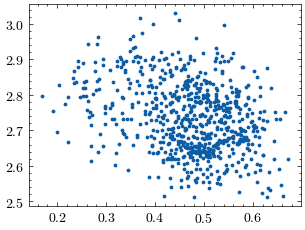

In [12]:
plt.scatter(center[:, 0], center[:, 1], s = 3)

In [13]:
positions = positions - center
velocities = velocities - center

In [14]:
center

array([[ 0.50727703,  2.63432962, -3.26189569],
       [ 0.50372589,  2.62710984, -3.28172274],
       [ 0.517708  ,  2.63231642, -3.28217857],
       ...,
       [ 0.28496305,  2.84340595, -3.27874028],
       [ 0.27280935,  2.80140698, -3.2660342 ],
       [ 0.31977582,  2.71922944, -3.22765587]])

### Saving BH quantities

In [15]:
pos_BH_1 = positions[0, :, :]
vel_BH_1 = velocities[0, :, :]

### Computing radial quantities

In [16]:
radius = []
for i in range(n_particles): radius.append(np.sqrt(positions[i, :, 0]**2 + positions[i, :, 1]**2 + positions[i, :, 2]**2))
radius = np.array(radius)

radius_at_t = []
for i in range(len(time)): radius_at_t.append(np.sqrt(positions[:, i, 0]**2 + positions[:, i, 1]**2 + positions[:, i, 2]**2))
radius_at_t = np.array(radius_at_t)

In [17]:
max(radius[:, 0])

np.float64(102651.02664471431)

In [18]:
radial_v = []
for i in range(n_particles): radial_v.append((positions[i, :, 0]*velocities[i, :, 0] + positions[i, :, 1]*velocities[i, :, 1] + positions[i, :, 2]*velocities[i, :, 2])/radius[i, :])
radial_v = np.array(radial_v)

### System mp4

### IU -> PU

In [19]:
#conversioni
MSOL_PER_IU = 1E10
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732  
#softening usato nel treecode
soft_pair = 0.06 # kpc

### System Energy

In [20]:
#Get the total energies from the log file, in the CM frame
def GetEnergy(filename, N):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U

    E = []
    K = []
    U = []
    t = []
    
    for i in idx:
        t.append(float(output[i+1].split()[0]))
        E.append(float(output[i + 1].split()[1]))
        K.append(float(output[i + 1].split()[2]))
        U.append(-float(output[i + 1].split()[3][:7]))
        
    #K = (np.array(K) - K_CM) * M_sun / v_iu_cgs**2
    #U = np.array(U) * G_p * 
    #E = np.add(K, U)

    file_output.close()
    return t, E, K, U

In [21]:
time_E, E, K, U = GetEnergy(logname, n_particles)

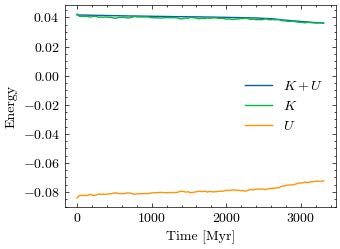

In [22]:
#plot of the energy
time_E = np.array(time_E) * MYR_PER_IU
plt.plot(time_E, E, label="$K + U$")
plt.plot(time_E, K, label="$K$")
plt.plot(time_E, U, label="$U$")
plt.xlabel("Time [Myr]")
plt.ylabel("Energy")
plt.legend()
plt.show()

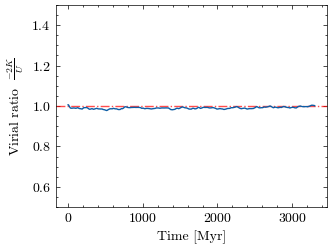

In [23]:
virial_ratio = []
for t in range(len(time_E)):
    virial_ratio.append(2 * K[t] / ( - U[t]))

virial_ratio = np.array(virial_ratio)
plt.axhline(1.0, color = 'r', linestyle = '-.', alpha = 0.7)
plt.plot(time_E, virial_ratio)
plt.xlabel('Time [Myr]')
plt.ylabel(r'Virial ratio $\,\, \frac{- 2K}{U}$')
plt.ylim(0.5, 1.5)
plt.show()

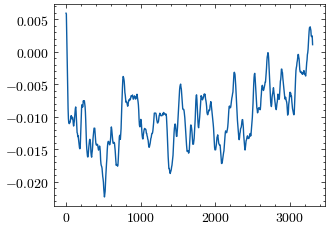

In [24]:
plt.plot(time_E, virial_ratio[:] - 1.0)

In [25]:
perc = max(virial_ratio[:] - 1.0) 
perc

np.float64(0.0059509640561770105)

In [26]:
print(2 * K[0] / np.abs(U[0]))

1.005950964056177


### Lagrangian radii

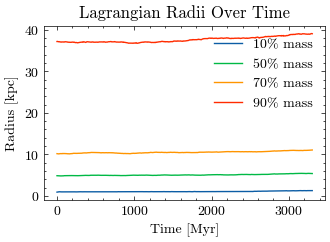

In [27]:
#compute Lagrangian radii enclosing specified mass fractions
def lagrangian_radii(pos, mass_fractions=[0.1, 0.5, 0.7, 0.9]):
    r = np.linalg.norm(pos, axis=1)  #radial distances
    r_sorted = np.sort(r)
    idxs = (np.array(mass_fractions) * len(r)).astype(int)  #indices for percentiles
    return r_sorted[idxs]

#lagrangian Radii over time
r_lag_all = []
for snap in range(snap_number):
    pos_snap = positions[:, snap, :]
    r_lag = lagrangian_radii(pos_snap)
    r_lag_all.append(r_lag)

r_lag_all = np.array(r_lag_all)

plt.figure()
for i, frac in enumerate([10, 50, 70, 90]):
    plt.plot(time*4.714829951118732, r_lag_all[:, i], label=f"{frac}% mass")

plt.xlabel("Time [Myr]")
plt.ylabel("Radius [kpc]")
plt.title("Lagrangian Radii Over Time")
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

### 2D orbit

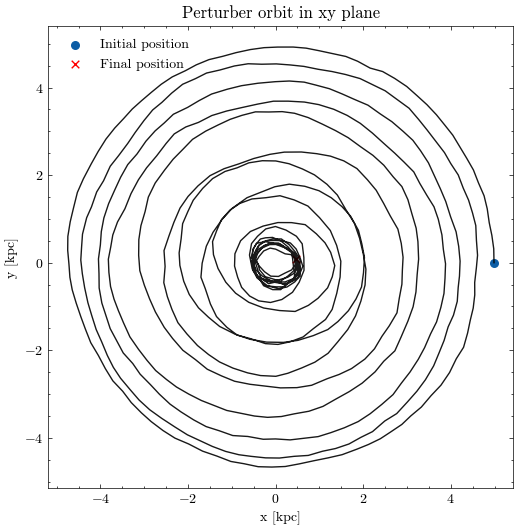

M_1 =  0.007


In [28]:
#coordinate dei due BH
x1, y1 = pos_BH_1[:, 0], pos_BH_1[:, 1]

plt.figure(figsize=(6,6))

#BH1 
plt.plot(x1, y1, c = 'black', linestyle = '-', alpha = 0.9)
plt.scatter([x1[0]], [y1[0]], c = 'C0', s=30, marker="o", label="Initial position")
plt.scatter([x1[-1]], [y1[-1]], s=30, c = 'r', marker="x", label = 'Final position')

#plt.plot(center[:,0], center[:,1], 'k--', lw=1)

plt.xlabel("x [kpc]")
plt.ylabel("y [kpc]")
plt.title("Perturber orbit in xy plane")
plt.legend()
plt.axis("equal")
#plt.ylim(-1, 1)
#plt.xlim(-1, 1)
plt.show()

print('M_1 = ', mass[0])

### BH radius

In [29]:
time_Myr = time * MYR_PER_IU

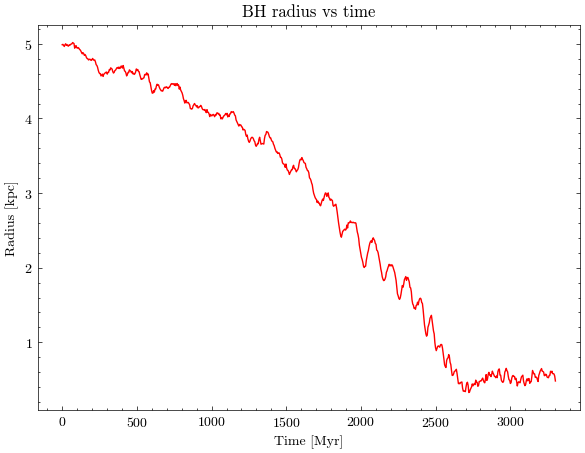

In [30]:
plt.figure(figsize=(7,5))
plt.plot(time_Myr, radius[0], color='red')
plt.xlabel("Time [Myr]")
plt.ylabel("Radius [kpc]")  # 1 IU = 1 kpc
plt.title("BH radius vs time")
plt.show()

### Angular momentum

In [31]:
r_rel_1 = pos_BH_1
v_rel_1 = vel_BH_1

L_BH = mass[0] * np.cross(r_rel_1, v_rel_1)
L_BH= np.sqrt(L_BH[:, 0]**2 + L_BH[:, 1]**2 + L_BH[:, 2]**2) #modulo rispetto al centro di massa

We fix the angular momentum threshold by taking the mean of the last snapshots, where we assume dynamical friction to have ended and the variation of L to be due to numerical noise.

In [32]:
time_Myr[600]

np.float64(2782.1252073656588)

In [33]:
L_conversion = 1 #MSOL_PER_IU * KPC_PER_IU**2 / MYR_PER_IU

In [34]:
L_threshold = np.mean(L_BH[600:]) * L_conversion
L_percent = L_threshold / L_BH[0]

print(f'|L| threshold = {L_threshold:.5f} corresponding to of {L_percent:.2f}% the initial value.')

|L| threshold = 0.01237 corresponding to of 0.09% the initial value.


In [35]:
interval = 5
xx = np.linspace(0, int(snap_number/interval) -  5, int(snap_number/interval) - 5, dtype = int) *5
means = [np.mean(L_BH[i:i+interval]) for i in xx]

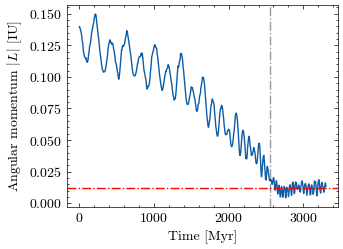

In [36]:
idx = np.array( np.where(np.isclose(means, L_threshold, atol = 1e-2))[0] )
t_idx = idx * interval

plt.plot(time_Myr, L_BH * L_conversion)
#plt.plot(time_Myr[xx], means)
plt.axhline(L_threshold * L_conversion, c = 'r', linestyle = '-.')
plt.xlabel("Time [Myr]")
plt.axvline(time_Myr[t_idx[1]], c = 'black', linestyle = '-.', alpha = 0.4)
plt.ylabel("Angular momentum $|L|$ [IU]")
plt.show()

In [37]:
idx

array([109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
       122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134,
       135, 136])

In [38]:
dt_df = max(time_Myr[t_idx[1]] - time_Myr[t_idx[0]], time_Myr[t_idx[2]] - time_Myr[t_idx[1]])

In [39]:
print(f'Esitimated t_df = {time_Myr[t_idx[0]]:.3f} +- {dt_df:.3f}')

Esitimated t_df = 2527.099 +- 23.184


In [40]:
time_Myr[t_idx[0]]

np.float64(2527.0987823055593)

### t_df from Orbital Energy

In [41]:
from scipy.interpolate import UnivariateSpline

In [42]:
def orbital_energy_single(time, r, v, M_host=1.0, a_h=2.0, G=1.0, smooth_factor=1e-3):
    """
    Calcola energia orbitale del BH singolo in un potenziale Hernquist
    """
    # energia orbitale specifica
    phi = - G * M_host / (r + a_h)
    v2 = np.sum(v**2, axis=1)
    E = 0.5 * v2 + phi

    # spline smoothata
    spline = UnivariateSpline(time, E, s=smooth_factor)
    E_smooth = spline(time)
    d2E = spline.derivative(1)(time)

    # trova primo zero-crossing concavità
    zero_cross = np.where(np.sign(d2E[:-1]) != np.sign(d2E[1:]))[0]
    t_df = None
    if len(zero_cross) > 0:
        t_df = time[zero_cross[2]]

    # --- Plot ---
    plt.figure(figsize=(7,5))
    plt.plot(time, E, color="gray", alpha=0.6, label=r"$E_1 \ \mathrm{(raw)}$")
    plt.plot(time, E_smooth, color="darkred", lw=2, label=r"$E_1 \ \mathrm{(spline)}$")
    if t_df:
        plt.axvline(t_df, color="gray", ls=":", lw=1.5,
                    label=rf"$t_{{DF}} \approx {t_df:.1f}$")
    plt.xlabel(r"$\mathrm{Time \ [Myr]}$")
    plt.ylabel(r"$E_1(t)$")
    plt.title(r"$\mathrm{Orbital \ Energy \ of \ BH1}$")
    plt.legend()
    plt.show()

    return t_df, E, E_smooth

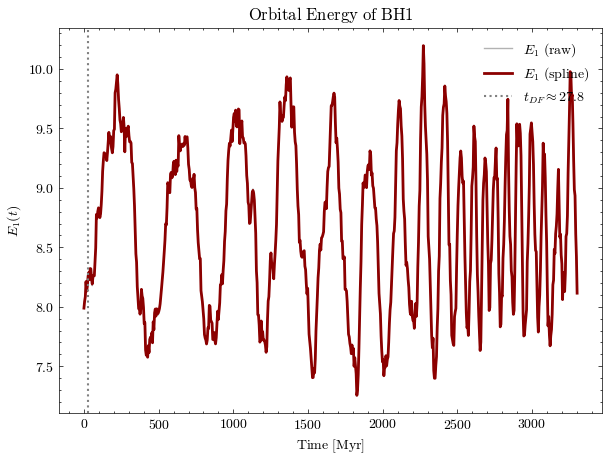

In [43]:
t_df_BH1_energy, E1, E1_smooth = orbital_energy_single(
    time_Myr, radius[0], vel_BH_1,
    M_host=1.0, a_h=2.0,
    G=1.0, smooth_factor=1e-2
)

### Escaped particles

In [44]:
M_H = 1.0
a = 2.0
r_escape = r_lag_all[0, -1]

def v_escape (radius):
    return np.sqrt(2*M_H / (radius + a))

n_escape = 0.0
mask_escape = []

for i in tqdm(range(1, n_particles)):
    for j in range(snap_number):
        if radius[i, j] > r_escape and radial_v[i, j] >= v_escape(r_escape):
            #print('particle number ', i, f'escaped at time {time[j]:.2f}')
            mask_escape.append(i)
            n_escape += 1
            break

print('tot # of escaped particles = ', n_escape, ', corresponding to ', n_escape/n_particles, ' of the system.')

100%|██████████████████████████████████████████████████████████████████████████| 30000/30000 [00:02<00:00, 11474.27it/s]

tot # of escaped particles =  2522.0 , corresponding to  0.08406386453784874  of the system.
